In [ ]:
# =============================================================================
# 1. SETUP: CARGA DE LIBRERÍAS Y MÓDULOS DEL PROYECTO
# =============================================================================
import sys
import time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from brian2 import *
import pandas as pd
import numpy as np

# 1. Configurar Path para encontrar 'src'
current_path = Path.cwd()
project_root = current_path
while not (project_root / 'src').exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("❌ No se encontró 'src'. Ejecuta desde la raíz del proyecto.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f"📍 Project Root añadido al path: {project_root}")

# 2. IMPORTACIONES ESPECÍFICAS (TUS FUNCIONES)
from src.two_populations.model import IzhikevichNetwork

# Métricas
from src.two_populations.metrics import analyze_simulation_results, print_network_statistics_table

# Plots Básicos
from src.two_populations.plots.basic_plots import (
    plot_raster_results, 
    plot_voltage_traces, 
    plot_spectrogram, 
    plot_correlation_matrix, 
    plot_cross_correlation_detailed
)

# Dashboards
from src.two_populations.plots.dashboard_plots import (
    plot_population_dashboard, 
    plot_connectivity_dashboard
)

# Estilo
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline
print("✅ Entorno 'src' cargado y listo.")

/home/tonicoll/.conda/envs/neurophysics/lib/python3.11/site-packages/setuptools/_distutils/_msvccompiler.py:12: UserWarning: _get_vc_env is private; find an alternative (pypa/distutils#340)
  warnings.warn(


📍 Project Root: /home/tonicoll/Projects/izhikevich
✅ Entorno cargado y listo para simulación detallada.


In [2]:
# =============================================================================
# 2. DEFINICIÓN DE LOS 3 CASOS REPRESENTATIVOS
# =============================================================================

# Configuración Global
SIM_DURATION = 5000 * ms  # 5 segundos para buena resolución espectral
DT = 0.1 * ms             # Paso de integración fino

# Los 3 Mosqueteros (Valores extraídos de tu análisis previo)
CASES = {
    'Asynchronous': {
        'k_intra': 1.6,
        'ratio': 0.14,
        'color': 'cyan',
        'desc': 'Baseline (Healthy)'
    },
    'Intermediate': {
        'k_intra': 2.4,
        'ratio': 0.63,
        'color': 'orange',
        'desc': 'Critical / Transition'
    },
    'Synchronous': {
        'k_intra': 13.2,
        'ratio': 0.55,
        'color': 'red',
        'desc': 'High Energy / Gamma'
    }
}

print(f"🔬 Preparando simulaciones para: {list(CASES.keys())}")
print(f"⏱️ Duración: {SIM_DURATION/second} segundos por caso.")

🔬 Preparando simulaciones para: ['Asynchronous', 'Intermediate', 'Synchronous']
⏱️ Duración: 5.0 segundos por caso.


In [28]:
# =============================================================================
# 3. MOTOR DE SIMULACIÓN (WRAPPER)
# =============================================================================

def run_specific_case(case_name, params):
    print(f"\n{'='*60}")
    print(f"🚀 EJECUTANDO CASO: {case_name.upper()}")
    print(f"   Param: k_intra={params['k_intra']}, Ratio={params['ratio']}")
    
    # 1. Calcular k_inter absoluto
    k_inter_abs = params['k_intra'] * params['ratio']
    
    # 2. Iniciar Red (Semilla fija para reproducibilidad exacta)
    net = IzhikevichNetwork(dt_val=DT/ms, T_total=SIM_DURATION/ms, 
                           fixed_seed=42, variable_seed=123, trial=0)
    
    # 3. Crear Poblaciones (Parámetros estándar del paper)
    # Asumimos Ne=800, Ni=200 y balance E/I = 3.9 (estándar tu proyecto)
    net.create_population2('A', k_exc=params['k_intra'], k_inh=params['k_intra']*3.9, 
                           noise_exc=0.88, noise_inh=0.6, rate_hz = 10.0)
    
    net.create_population2('B', k_exc=params['k_intra'], k_inh=params['k_intra']*3.9, 
                           noise_exc=0.88, noise_inh=0.6, rate_hz = 10.0)
    
    # 4. Conectar (Bidireccional)
    # Delay 0.0 ms (Baseline sin retraso)
    net.connect_populations('A', 'B', p_inter=0.02, weight_scale=k_inter_abs, delay_value=0.0)
    net.connect_populations('B', 'A', p_inter=0.02, weight_scale=k_inter_abs, delay_value=0.0)
    
    # 5. Monitores
    # Grabamos LFP (v_mean) y Spikes. Sampleamos LFP a 1000Hz (dt=1ms) para ahorrar RAM
    net.setup_monitors(['A', 'B'], record_v_dt=0.5, sample_fraction=0.5)
    
    # 6. Correr
    results = net.run_simulation()
    print(f"✅ Simulación completada para {case_name}")
    return results

# Almacén de resultados
dataset = {}

In [29]:
# =============================================================================
# 4. EJECUCIÓN DE LAS SIMULACIONES
# =============================================================================
import time

start_total = time.time()

for name, params in CASES.items():
    # Ejecutar y guardar en el diccionario
    dataset[name] = run_specific_case(name, params)

print(f"\n🏁 Todo listo. Tiempo total: {(time.time() - start_total):.1f}s")

SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 0, 'fixed_seed_A': 41, 'fixed_seed_B': 43, 'fixed_seed_common': 42, 'variable_common_current': 123, 'variable_A_current': 123, 'variable_B_current': 126}



🚀 EJECUTANDO CASO: ASYNCHRONOUS
   Param: k_intra=1.6, Ratio=0.14


INFO     | src.two_populations.model:_create_stimulus2:290 - Creating Poisson for A with seed state: 122
INFO     | src.two_populations.model:_create_stimulus2:352 - PoissonGroup A: 100 sources @ 10.0Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:267 - Population A (PoissonInput): 800E/200I, 79623+20045 syn
INFO     | src.two_populations.model:_create_stimulus2:290 - Creating Poisson for B with seed state: 124
INFO     | src.two_populations.model:_create_stimulus2:352 - PoissonGroup B: 100 sources @ 10.0Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:267 - Population B (PoissonInput): 800E/200I, 80737+20045 syn
INFO     | src.two_populations.model:connect_populations:480 - Connecting A->B using seeds: fixed=42, variable(current)=123
INFO     | src.two_populations.model:connect_populations:501 - Distribución de pesos y conectividad inter: weight_dist='constant' , k_base=0.5 , weight_scale=0.22400000

✅ Simulación completada para Asynchronous

🚀 EJECUTANDO CASO: INTERMEDIATE
   Param: k_intra=2.4, Ratio=0.63


SUCCESS  | src.two_populations.model:__init__:45 - Network initialized with seeds: {'trial': 0, 'fixed_seed_A': 41, 'fixed_seed_B': 43, 'fixed_seed_common': 42, 'variable_common_current': 123, 'variable_A_current': 123, 'variable_B_current': 126}
INFO     | src.two_populations.model:_create_stimulus2:290 - Creating Poisson for A with seed state: 122
INFO     | src.two_populations.model:_create_stimulus2:352 - PoissonGroup A: 100 sources @ 10.0Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:267 - Population A (PoissonInput): 800E/200I, 79623+20045 syn
INFO     | src.two_populations.model:_create_stimulus2:290 - Creating Poisson for B with seed state: 124
INFO     | src.two_populations.model:_create_stimulus2:352 - PoissonGroup B: 100 sources @ 10.0Hz → 80000 exc + 20000 inh synapses
INFO     | src.two_populations.model:create_population2:267 - Population B (PoissonInput): 800E/200I, 80737+20045 syn
INFO     | src.two_populations.model:connect_

✅ Simulación completada para Intermediate

🚀 EJECUTANDO CASO: SYNCHRONOUS
   Param: k_intra=13.2, Ratio=0.55
✅ Simulación completada para Synchronous

🏁 Todo listo. Tiempo total: 292.5s


In [43]:
# =============================================================================
# 5. REPORTE DE MÉTRICAS (CORREGIDO: MODO FIRING RATE)
# =============================================================================
import numpy as np

metrics_summary = {}

print(f"{'='*60}")
print(f"📊 REPORTE DE MÉTRICAS (Usando Spikes)")
print(f"{'='*60}")

for name, results in dataset.items():
    
    # 1. Monitores
    spikes_A = results['A']['spike_monitor']
    spikes_B = results['B']['spike_monitor']
    
    # NOTA: Pasamos state_monitors como None o vacío para evitar que 
    # la función intente leer voltaje si no existe.
    # El análisis se basará puramente en los spikes (que sí tenemos).
    
    # 2. Llamada a análisis (CAMBIO CLAVE: signal_mode='firing_rate')
    try:
        m = analyze_simulation_results(
            spike_mon_A=spikes_A,
            spike_mon_B=spikes_B,
            N=1000,
            condition_name=name,
            warmup=500.0,
            state_monitors=None, # <--- Lo quitamos para evitar el error de .v
            T_total=SIM_DURATION/ms,
            signal_mode='firing_rate' # <--- USAMOS SPIKES, NO VOLTAJE
        )
        metrics_summary[name] = m
        
        # 3. EXTRACCIÓN DE DATOS
        # Rate: Promedio de la serie temporal 'fr_A'
        ts_rate = m['time_series']['fr_A']
        mean_rate = np.mean(ts_rate)

        # Sincronía
        cc_peak = m.get('cross_corr_peak', 0.0)
        plv = m.get('plv_alpha', 0.0)
        
        # Potencia (calculada sobre el histograma de spikes)
        gamma_pow = m.get('power_A', {}).get('gamma_power', 0.0)
        
        print(f"\n🔹 {name.upper()}")
        print(f"   -> Rate Medio:   {mean_rate:.2f} Hz")
        print(f"   -> CC Peak:      {cc_peak:.3f}")
        print(f"   -> PLV Alpha:    {plv:.3f}")
        # Si gamma_pow es muy bajo, es normal en modo firing_rate, lo importante es el pico relativo
        print(f"   -> Gamma Power:  {gamma_pow:.2e}")
        
    except Exception as e:
        print(f"\n❌ Error analizando {name}: {e}")

print("-" * 60)

INFO     | src.two_populations.metrics:analyze_simulation_results:627 - 
=== Asynchronous (firing_rate) ===
INFO     | src.two_populations.metrics:analyze_simulation_results:629 - Cross-corr: 0.150 @ -2.2ms
INFO     | src.two_populations.metrics:analyze_simulation_results:630 - Alpha PLV: 0.059, PLI: 0.059
INFO     | src.two_populations.metrics:analyze_simulation_results:631 - Coherence: 0.377 @ 33.0Hz
INFO     | src.two_populations.metrics:analyze_simulation_results:632 - Timescales: A=1.0ms, B=1.3ms
INFO     | src.two_populations.metrics:analyze_simulation_results:627 - 
=== Intermediate (firing_rate) ===
INFO     | src.two_populations.metrics:analyze_simulation_results:629 - Cross-corr: 0.784 @ -1.4ms
INFO     | src.two_populations.metrics:analyze_simulation_results:630 - Alpha PLV: 0.966, PLI: 0.127
INFO     | src.two_populations.metrics:analyze_simulation_results:631 - Coherence: 0.897 @ 8.0Hz
INFO     | src.two_populations.metrics:analyze_simulation_results:632 - Timescales: A=0.

INFO     | src.two_populations.metrics:analyze_simulation_results:627 - 
=== Synchronous (firing_rate) ===
INFO     | src.two_populations.metrics:analyze_simulation_results:629 - Cross-corr: 0.916 @ -0.1ms
INFO     | src.two_populations.metrics:analyze_simulation_results:630 - Alpha PLV: 0.999, PLI: 0.518
INFO     | src.two_populations.metrics:analyze_simulation_results:631 - Coherence: 0.983 @ 21.0Hz
INFO     | src.two_populations.metrics:analyze_simulation_results:632 - Timescales: A=0.1ms, B=8.7ms


📊 REPORTE DE MÉTRICAS (Usando Spikes)

🔹 ASYNCHRONOUS
   -> Rate Medio:   7.43 Hz
   -> CC Peak:      0.150
   -> PLV Alpha:    0.059
   -> Gamma Power:  1.30e+00

🔹 INTERMEDIATE
   -> Rate Medio:   9.50 Hz
   -> CC Peak:      0.784
   -> PLV Alpha:    0.966
   -> Gamma Power:  5.84e+00

🔹 SYNCHRONOUS
   -> Rate Medio:   33.05 Hz
   -> CC Peak:      0.916
   -> PLV Alpha:    0.999
   -> Gamma Power:  1.44e+02
------------------------------------------------------------


In [41]:
for i, (k, v) in enumerate(metrics_summary['Synchronous'].items()):
    print(f"{i}: {k} {type(v)}")
    
    try: 
        
        for j, (k2, v2) in enumerate(v.items()):
            print(f"  {j}: {k2}")
    except:
        print(v)
        pass


0: signal_mode <class 'str'>
firing_rate
1: single_population <class 'bool'>
False
2: time_series <class 'dict'>
  0: time
  1: signal_A
  2: signal_B
  3: time_fr
  4: fr_A
  5: fr_B
3: cross_correlation <class 'dict'>
  0: lags
  1: correlation
  2: peak_lag
  3: peak_value
  4: lag_sign_convention
4: phase_locking <class 'dict'>
  0: theta
  1: alpha
  2: beta
  3: gamma
  4: broadband
5: coherence <class 'dict'>
  0: freqs
  1: coherence
  2: peak_freq
  3: peak_coherence
  4: theta_coherence
  5: alpha_coherence
  6: beta_coherence
  7: gamma_coherence
  8: broad_coherence
6: power_A <class 'dict'>
  0: freqs
  1: psd
  2: alpha_power
  3: beta_power
  4: gamma_power
  5: total_power
  6: peak_freq
  7: peak_power
7: power_B <class 'dict'>
  0: freqs
  1: psd
  2: alpha_power
  3: beta_power
  4: gamma_power
  5: total_power
  6: peak_freq
  7: peak_power
8: timescale_A <class 'dict'>
  0: tau_exp
  1: tau_int
  2: quality
9: timescale_B <class 'dict'>
  0: tau_exp
  1: tau_int
  


🖼️  RASTER PLOT: ASYNCHRONOUS


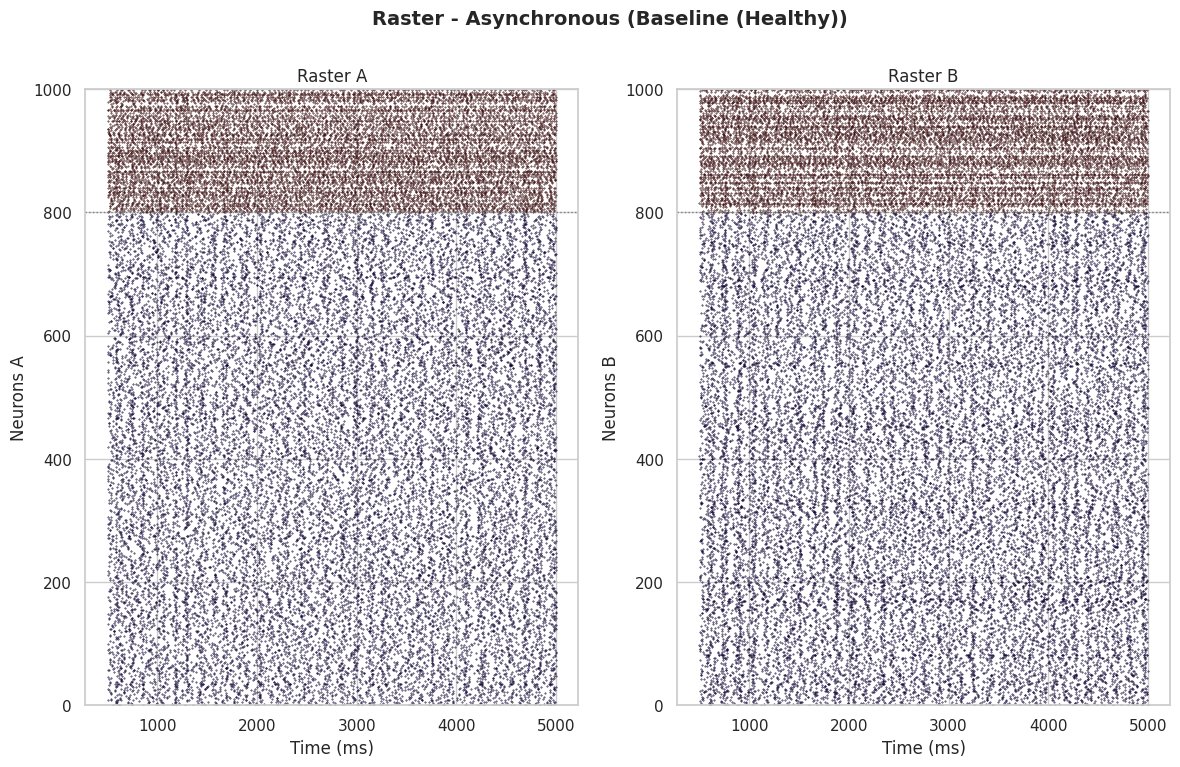


🖼️  RASTER PLOT: INTERMEDIATE


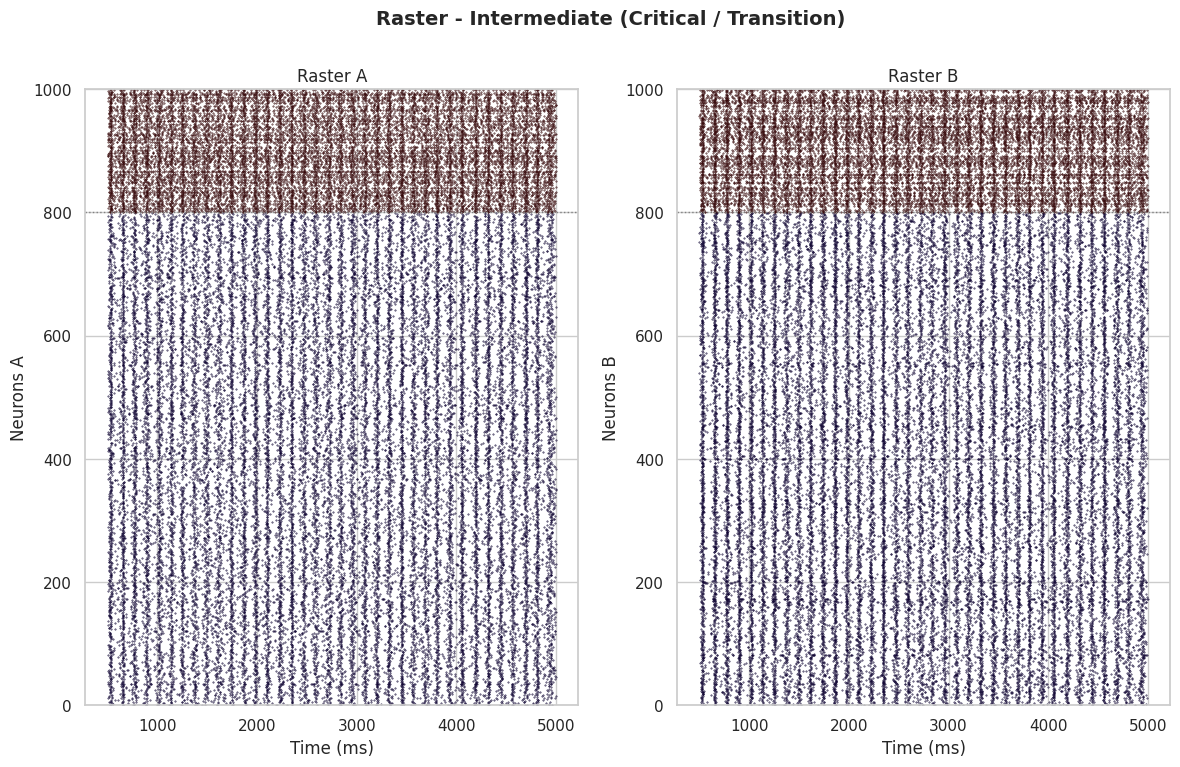


🖼️  RASTER PLOT: SYNCHRONOUS


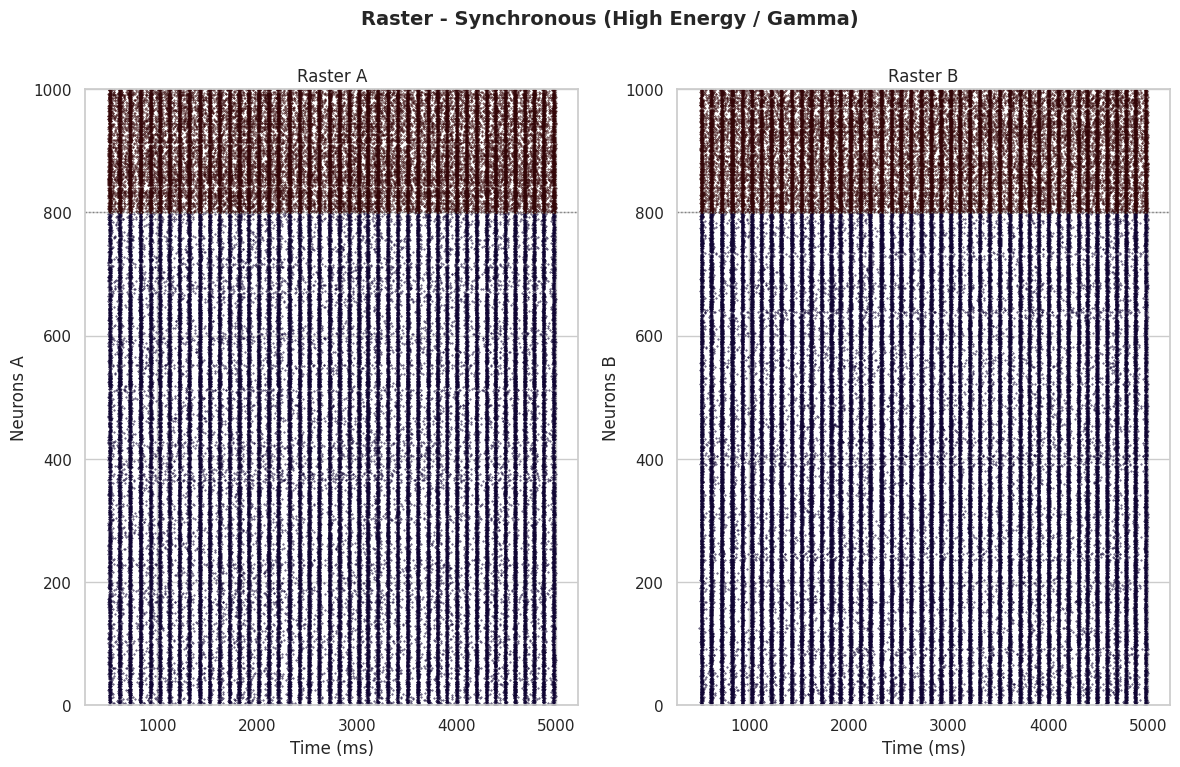

In [31]:
# =============================================================================
# 5. VISUALIZACIÓN: RASTERS (CORREGIDO - FIRMA REAL DETECTADA)
# =============================================================================
import matplotlib.pyplot as plt

# La firma detectada es:
# def plot_raster_results(results, N_exc=800, N_total=1000, warmup_ms=500, neuron_limit=None)

for name, results in dataset.items():
    print(f"\n{'='*60}")
    print(f"🖼️  RASTER PLOT: {name.upper()}")
    
    # 1. Check de sanidad (opcional, pero buena práctica)
    # Accedemos a los monitores dentro del diccionario results
    spikes_A = results['A']['spike_monitor']
    spikes_B = results['B']['spike_monitor']
    
    if len(spikes_A.t) == 0 and len(spikes_B.t) == 0:
        print("    ⚠️ ADVERTENCIA: No hay espigas para plotear.")
        continue

    # 2. LLAMADA A LA FUNCIÓN (Usando la firma correcta)
    # Pasamos el diccionario 'results' completo, no los monitores sueltos.
    # Los argumentos N_exc, N_total y warmup_ms tienen valores por defecto que parecen correctos.
    try:
        # La función devuelve una figura, la capturamos para modificarla si es necesario
        fig = plot_raster_results(results)
        
        # 3. DECORACIÓN EXTERNA
        # Como la función no acepta título, usamos plt.suptitle o ax.set_title sobre la figura activa
        # Buscamos el axes activo o ponemos un suptitle
        if fig:
            fig.suptitle(f"Raster - {name} ({CASES[name]['desc']})", fontsize=14, fontweight='bold', y=0.98)
            
        plt.show()
        
    except Exception as e:
        print(f"❌ Error al generar el raster plot: {e}")
        # Fallback simple en caso de que falle la función interna
        plt.figure(figsize=(10, 5))
        plt.plot(spikes_A.t/ms, spikes_A.i, '|k', markersize=2, alpha=0.5, label='Pop A')
        # Desplazamos B para que no se superponga (si N=1000, B empieza en 1000 visualmente o se mezcla)
        # Asumiendo índices globales o separados. Si son separados:
        plt.plot(spikes_B.t/ms, spikes_B.i + 1000, '|r', markersize=2, alpha=0.5, label='Pop B') 
        plt.title(f"Fallback Raster: {name}")
        plt.xlabel("Time (ms)")
        plt.ylabel("Neuron Index")
        plt.legend()
        plt.show()

In [47]:
print_network_statistics_table(m)

TypeError: print_network_statistics_table() missing 1 required positional argument: 'network'

In [44]:
# =============================================================================
# 5. VISUALIZACIÓN: DASHBOARDS GENERALES
# =============================================================================

for name, results in dataset.items():
    print(f"\n{'='*80}")
    print(f"🎛️ DASHBOARD: {name.upper()}")
    print(f"{'='*80}")
    
    # Intentamos pasar los resultados a tu dashboard. 
    # Verifica si tu función acepta 'results' dict o necesita argumentos sueltos.
    # Asumo que acepta el diccionario de resultados y las métricas calculadas.
    try:
        plot_population_dashboard(
            results, 
            metrics=metrics_data[name], 
            title=f"{name} ({CASES[name]['desc']})",
            T_total=SIM_DURATION/ms
        )
        plt.show()
    except Exception as e:
        print(f"⚠️ Error en dashboard: {e}")
        # Fallback manual a Raster
        plot_raster_results(
            results['A']['spike_monitor'], 
            results['B']['spike_monitor'], 
            duration=SIM_DURATION/ms, 
            title=f"Raster Fallback - {name}"
        )
        plt.show()


🎛️ DASHBOARD: ASYNCHRONOUS
⚠️ Error en dashboard: name 'metrics_data' is not defined


TypeError: plot_raster_results() got an unexpected keyword argument 'duration'

TypeError: plot_voltage_traces() got an unexpected keyword argument 'neuron_indices'

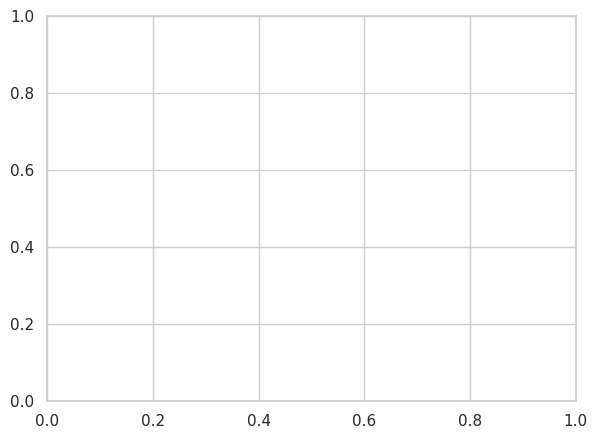

In [45]:
# =============================================================================
# 6. DETALLES: ESPECTROGRAMA Y VOLTAJE
# =============================================================================

for name, results in dataset.items():
    fig = plt.figure(figsize=(15, 5))
    
    # 1. Trazas de Voltaje (Zoom de 500ms)
    plt.subplot(1, 2, 1)
    plot_voltage_traces(
        results['A']['state_monitor'], 
        neuron_indices=[0, 1, 2], 
        time_window=[2000, 2500], # Zoom en el medio
        title=f"Voltajes - {name}"
    )
    
    # 2. Espectrograma (Para ver si la oscilación es estable o intermitente)
    # plot_spectrogram suele crear su propia figura, así que lo llamamos aparte
    plt.tight_layout()
    plt.show()
    
    print(f"   -> Generando Espectrograma para {name}...")
    plot_spectrogram(
        results['A']['state_monitor'], 
        fs=1000, # 1000Hz porque dt_record=1.0ms
        title=f"Espectrograma - {name}"
    )
    plt.show()